# Applicability domain and model-risk control

This notebook asks a deployment question rather than another optimisation question:

> **When should a scientific model widen uncertainty, flag a prediction, or abstain because the requested experiment lies outside validated support?**

The experiment is controlled. Latent efficacy is used only for final audit metrics.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from crop_protection_ps.model_risk import (
    ModelRiskConfig,
    simulate_model_risk_audit,
    summarise_model_risk,
)

## Locked audit design

Each rollout separates **model fitting**, **in-domain calibration**, **near-shift calibration**, and the **final stress test**. The final stress set contains in-domain, near-shift and far-shift conditions that are not used to choose the applicability threshold or conformal widths.

In [2]:
config = ModelRiskConfig()
rollouts, example = simulate_model_risk_audit(config)
summary = summarise_model_risk(rollouts)

pd.DataFrame(summary["metrics"]).T

,mean,mc95_low,mc95_high
acceptance_rate,0.210385,0.206192,0.214578
always_predict_mae,0.169488,0.166585,0.172391
distance_scaled_interval_coverage,0.928654,0.922087,0.935221
mean_global_interval_width,0.430782,0.418045,0.443519
mean_scaled_interval_width,0.825516,0.807697,0.843336
naive_id_interval_coverage,0.506462,0.494814,0.518109
ood_rejection_rate,0.981000,0.977735,0.984265
selective_interval_coverage,0.888949,0.875113,0.902786
selective_mae,0.050160,0.049069,0.051252
stress_global_interval_coverage,0.699692,0.689550,0.709834


## Interval calibration under shift

Three uncertainty strategies are compared:

1. an in-domain 90% conformal interval reused everywhere;
2. one global interval calibrated with an additional near-shift challenge set;
3. a distance-scaled interval whose width grows quadratically beyond the applicability threshold.

The third strategy can recover coverage, but the width itself becomes a model-risk signal.

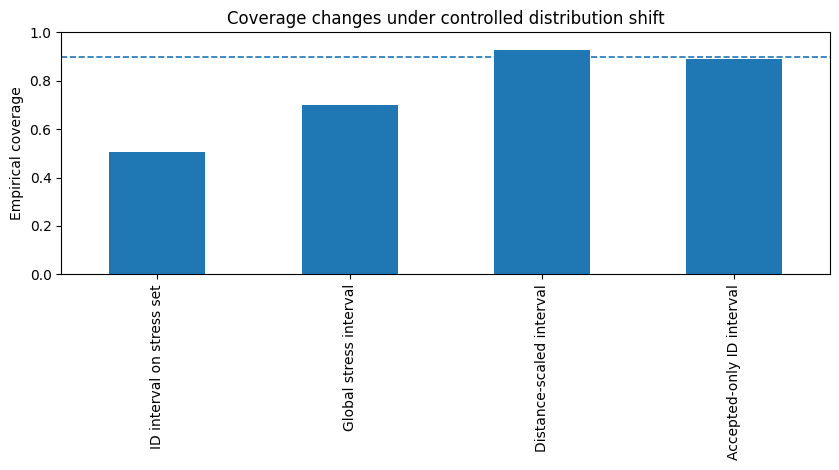

In [3]:
coverage = pd.Series({
    "ID interval on stress set": rollouts["naive_id_interval_coverage"].mean(),
    "Global stress interval": rollouts["stress_global_interval_coverage"].mean(),
    "Distance-scaled interval": rollouts["distance_scaled_interval_coverage"].mean(),
    "Accepted-only ID interval": rollouts["selective_interval_coverage"].mean(),
})
ax = coverage.plot(kind="bar", figsize=(8.5, 4.8))
ax.axhline(config.nominal_coverage, linestyle="--", linewidth=1.2)
ax.set_ylim(0, 1)
ax.set_ylabel("Empirical coverage")
ax.set_title("Coverage changes under controlled distribution shift")
plt.tight_layout()
plt.show()

## Applicability-domain abstention

The operating rule accepts a prediction only when its mean seven-nearest-neighbour distance is below the 85th percentile of in-domain calibration distances. The threshold is deliberately fixed before final stress testing.

In [4]:
gate = pd.Series(summary["promotion_gate"])
gate

minimum_distance_scaled_coverage                                                              0.9
minimum_selective_coverage                                                                   0.87
minimum_ood_rejection_rate                                                                   0.95
minimum_selective_mae_reduction_percent                                                      60.0
observed_distance_scaled_coverage                                                        0.928654
observed_selective_coverage                                                              0.888949
observed_ood_rejection_rate                                                                 0.981
observed_selective_mae_reduction_percent                                                 70.40482
paired_coverage_gain_scaled_minus_global        {'mean': 0.22896153846153847, 'mc95_low': 0.21...
paired_mae_difference_selective_minus_always    {'mean': -0.11932761754416045, 'mc95_low': -0....
promoted            

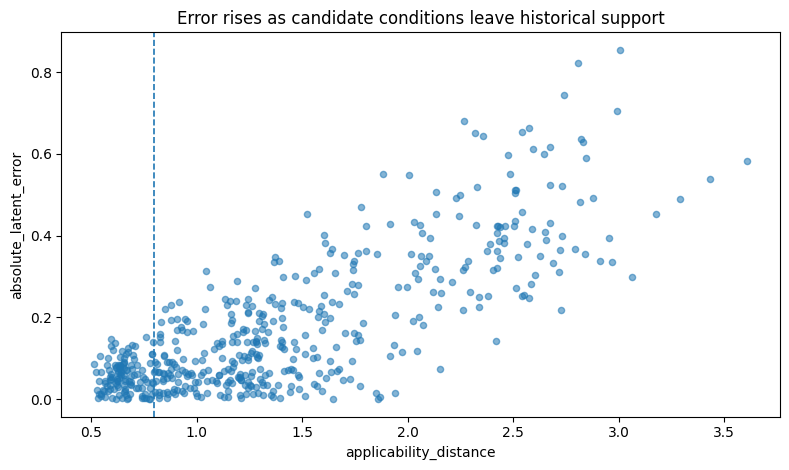

In [5]:
ax = example.plot.scatter(
    x="applicability_distance",
    y="absolute_latent_error",
    figsize=(8.0, 4.8),
    alpha=0.55,
)
threshold = rollouts.loc[0, "acceptance_threshold"]
ax.axvline(threshold, linestyle="--", linewidth=1.2)
ax.set_title("Error rises as candidate conditions leave historical support")
plt.tight_layout()
plt.show()

## Interpretation

The controlled result is intentionally not “uncertainty fixes extrapolation.” Distance-aware widening restores approximate coverage only by making far-shift intervals very wide. At that point the scientifically useful action can be **abstention plus a new experiment**, not a more confident-looking number.

The deployment principle is:

\[oxed{	ext{model can compute a prediction} 
eq 	ext{prediction is inside validated scientific support}}\]